# Tugas Besar 2 IF3270 — CNN & RNN/LSTM Image Captioning

Notebook ini menjalankan seluruh eksperimen sesuai spesifikasi:

- 1  Setup & Shared Utilities
- 2  CNN — Training (16-variant hyperparameter sweep)
- 3  CNN — From Scratch & Evaluation
- 4  CNN — Grad-CAM [Bonus]
- 5  RNN/LSTM — Feature Extraction + Caption Preprocessing
- 6  RNN/LSTM — Training (RNN & LSTM variants)
- 7  RNN/LSTM — From Scratch & Evaluation
- 8  RNN/LSTM — Beam Search / Init-Inject [Bonus]


## 1 Setup & Shared Utilities

In [14]:
import os
import sys
import json
import time
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('project root:', ROOT)

project root: /workspace


In [2]:
DATA_DIR = ROOT / 'data'
INTEL_DIR = DATA_DIR / 'intel'
FLICKR_DIR = DATA_DIR / 'flickr8k'
FEAT_DIR = FLICKR_DIR / 'features'
CAP_DIR = FLICKR_DIR / 'captions'

MODELS_DIR = ROOT / 'models'
OUT_DIR = ROOT / 'outputs'
for p in [FEAT_DIR, CAP_DIR, MODELS_DIR / 'cnn', MODELS_DIR / 'rnn', MODELS_DIR / 'lstm', OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

In [3]:
import zipfile
for z, dst in [("intel.zip", "data/intel"), ("flickr8k.zip", "data/flickr8k"), ("cnn_weights.zip", "models/cnn")]:
    if not Path(dst).exists():
        Path(dst).parent.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(drive_root / z) as zf:
            zf.extractall(Path(dst).parent)

In [4]:
from src.shared.image_utils import load_image, load_batch, extract_and_save_features
from src.shared.activations import relu, softmax, sigmoid, tanh
from src.shared.dense_layer import DenseLayer

# sanity check on the activations
x = np.array([-1.0, 0.0, 1.0, 2.0])
print('relu  :', relu(x))
print('softmax:', softmax(x))
print('sigmoid:', sigmoid(x))
print('tanh  :', tanh(x))

relu  : [0. 0. 1. 2.]
softmax: [0.0320586  0.08714432 0.23688282 0.64391426]
sigmoid: [0.26894142 0.5        0.73105858 0.88079708]
tanh  : [-0.76159416  0.          0.76159416  0.96402758]


## 2 CNN — Training (hyperparameter sweep)

Spec Bagian 3: 16 architectures = 2 (num layers) x 2 (filter combos) x 2 (kernel) x 2 (pooling).
Loss: Sparse Categorical Crossentropy, Optimizer: Adam, metric: macro F1 (custom callback).
Dataset: Intel Image Classification (6 classes, train/val/test sudah dibagi).

In [5]:
import tensorflow as tf
from tensorflow import keras
from src.cnn.train import CNNConfig, hyperparameter_grid, train_grid, save_artefacts

IMG_SIZE = (150, 150)
BATCH = 32
EPOCHS = 15

train_dir = INTEL_DIR / 'seg_train' / 'seg_train'
test_dir  = INTEL_DIR / 'seg_test'  / 'seg_test'

raw_train = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, label_mode='int',
    validation_split=0.15, subset='training', seed=42,
)
raw_val = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH, label_mode='int',
    validation_split=0.15, subset='validation', seed=42,
)
raw_test = keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH, label_mode='int', shuffle=False,
)
class_names = raw_train.class_names
print('classes:', class_names)

normalise = keras.layers.Rescaling(1.0 / 255.0)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train.map(lambda x, y: (normalise(x), y)).prefetch(AUTOTUNE)
val_ds   = raw_val.map(lambda x, y: (normalise(x), y)).prefetch(AUTOTUNE)
test_ds  = raw_test.map(lambda x, y: (normalise(x), y)).prefetch(AUTOTUNE)

I0000 00:00:1778946874.200275 1531877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778946874.243435 1531877 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778946875.225102 1531877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 14034 files belonging to 6 classes.
Using 11929 files for training.


W0000 00:00:1778946876.411902 1531877 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778946876.418818 1531877 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778946876.511448 1531877 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1483 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Found 14034 files belonging to 6 classes.
Using 2105 files for validation.
Found 3000 files belonging to 6 classes.
classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [6]:
# Build the 16-variant sweep and train.
configs = hyperparameter_grid(epochs=EPOCHS, batch_size=BATCH, input_shape=IMG_SIZE + (3,), num_classes=len(class_names))
print('total CNN variants:', len(configs))
for c in configs:
    print(' -', c.variant_name())

cnn_results = train_grid(
    configs,
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    output_root=MODELS_DIR / 'cnn',
    verbose=1,
)

total CNN variants: 16
 - l2_f32-64_k3_max
 - l2_f32-64_k3_avg
 - l2_f32-64_k5_max
 - l2_f32-64_k5_avg
 - l2_f16-32_k3_max
 - l2_f16-32_k3_avg
 - l2_f16-32_k5_max
 - l2_f16-32_k5_avg
 - l4_f32-64-128-256_k3_max
 - l4_f32-64-128-256_k3_avg
 - l4_f32-64-128-256_k5_max
 - l4_f32-64-128-256_k5_avg
 - l4_f16-32-64-128_k3_max
 - l4_f16-32-64-128_k3_avg
 - l4_f16-32-64-128_k5_max
 - l4_f16-32-64-128_k5_avg


[1/16] Skipping l2_f32-64_k3_max; saved artefacts found.


[2/16] Skipping l2_f32-64_k3_avg; saved artefacts found.


[3/16] Skipping l2_f32-64_k5_max; saved artefacts found.


[4/16] Skipping l2_f32-64_k5_avg; saved artefacts found.


...

[12/16] Skipping l4_f32-64-128-256_k5_avg; saved artefacts found.


[13/16] Skipping l4_f16-32-64-128_k3_max; saved artefacts found.


[14/16] Skipping l4_f16-32-64-128_k3_avg; saved artefacts found.


[15/16] Skipping l4_f16-32-64-128_k5_max; saved artefacts found.


[16/16] Skipping l4_f16-32-64-128_k5_avg; saved artefacts found.


In [7]:
# Build a summary table of all variants and pick the best one for 3.
rows = []
for variant, art in cnn_results.items():
    rows.append({
        'variant': variant,
        'test_macro_f1': art['test_macro_f1'],
        'elapsed_sec': art['elapsed_seconds'],
        'num_layers': art['config']['num_conv_layers'],
        'filters': art['config']['filters_per_layer'][:art['config']['num_conv_layers']],
        'kernel': art['config']['kernel_size'],
        'pooling': art['config']['pooling_type'],
    })
rows.sort(key=lambda r: (r['test_macro_f1'] if r['test_macro_f1'] is not None else -1), reverse=True)
for r in rows:
    print(r)

best_cnn_variant = rows[0]['variant']
print('best CNN variant:', best_cnn_variant)
with open(OUT_DIR / 'cnn_sweep_results.json', 'w', encoding='utf-8') as f:
    json.dump(rows, f, indent=2)

{'variant': 'l4_f32-64-128-256_k5_max', 'test_macro_f1': 0.8569575701404606, 'elapsed_sec': 3686.245994567871, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 5, 'pooling': 'max'}
{'variant': 'l4_f32-64-128-256_k3_max', 'test_macro_f1': 0.8528396963467663, 'elapsed_sec': 1754.3369722366333, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 3, 'pooling': 'max'}
{'variant': 'l4_f16-32-64-128_k3_max', 'test_macro_f1': 0.8501190289182551, 'elapsed_sec': 714.1509511470795, 'num_layers': 4, 'filters': [16, 32, 64, 128], 'kernel': 3, 'pooling': 'max'}
{'variant': 'l4_f32-64-128-256_k3_avg', 'test_macro_f1': 0.8479696983364357, 'elapsed_sec': 1840.5515081882477, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 3, 'pooling': 'avg'}
{'variant': 'l4_f32-64-128-256_k5_avg', 'test_macro_f1': 0.8454573401530774, 'elapsed_sec': 3820.195597410202, 'num_layers': 4, 'filters': [32, 64, 128, 256], 'kernel': 5, 'pooling': 'avg'}
{'variant': 'l4_f16-32-64-128_k3_avg', 'test_macro

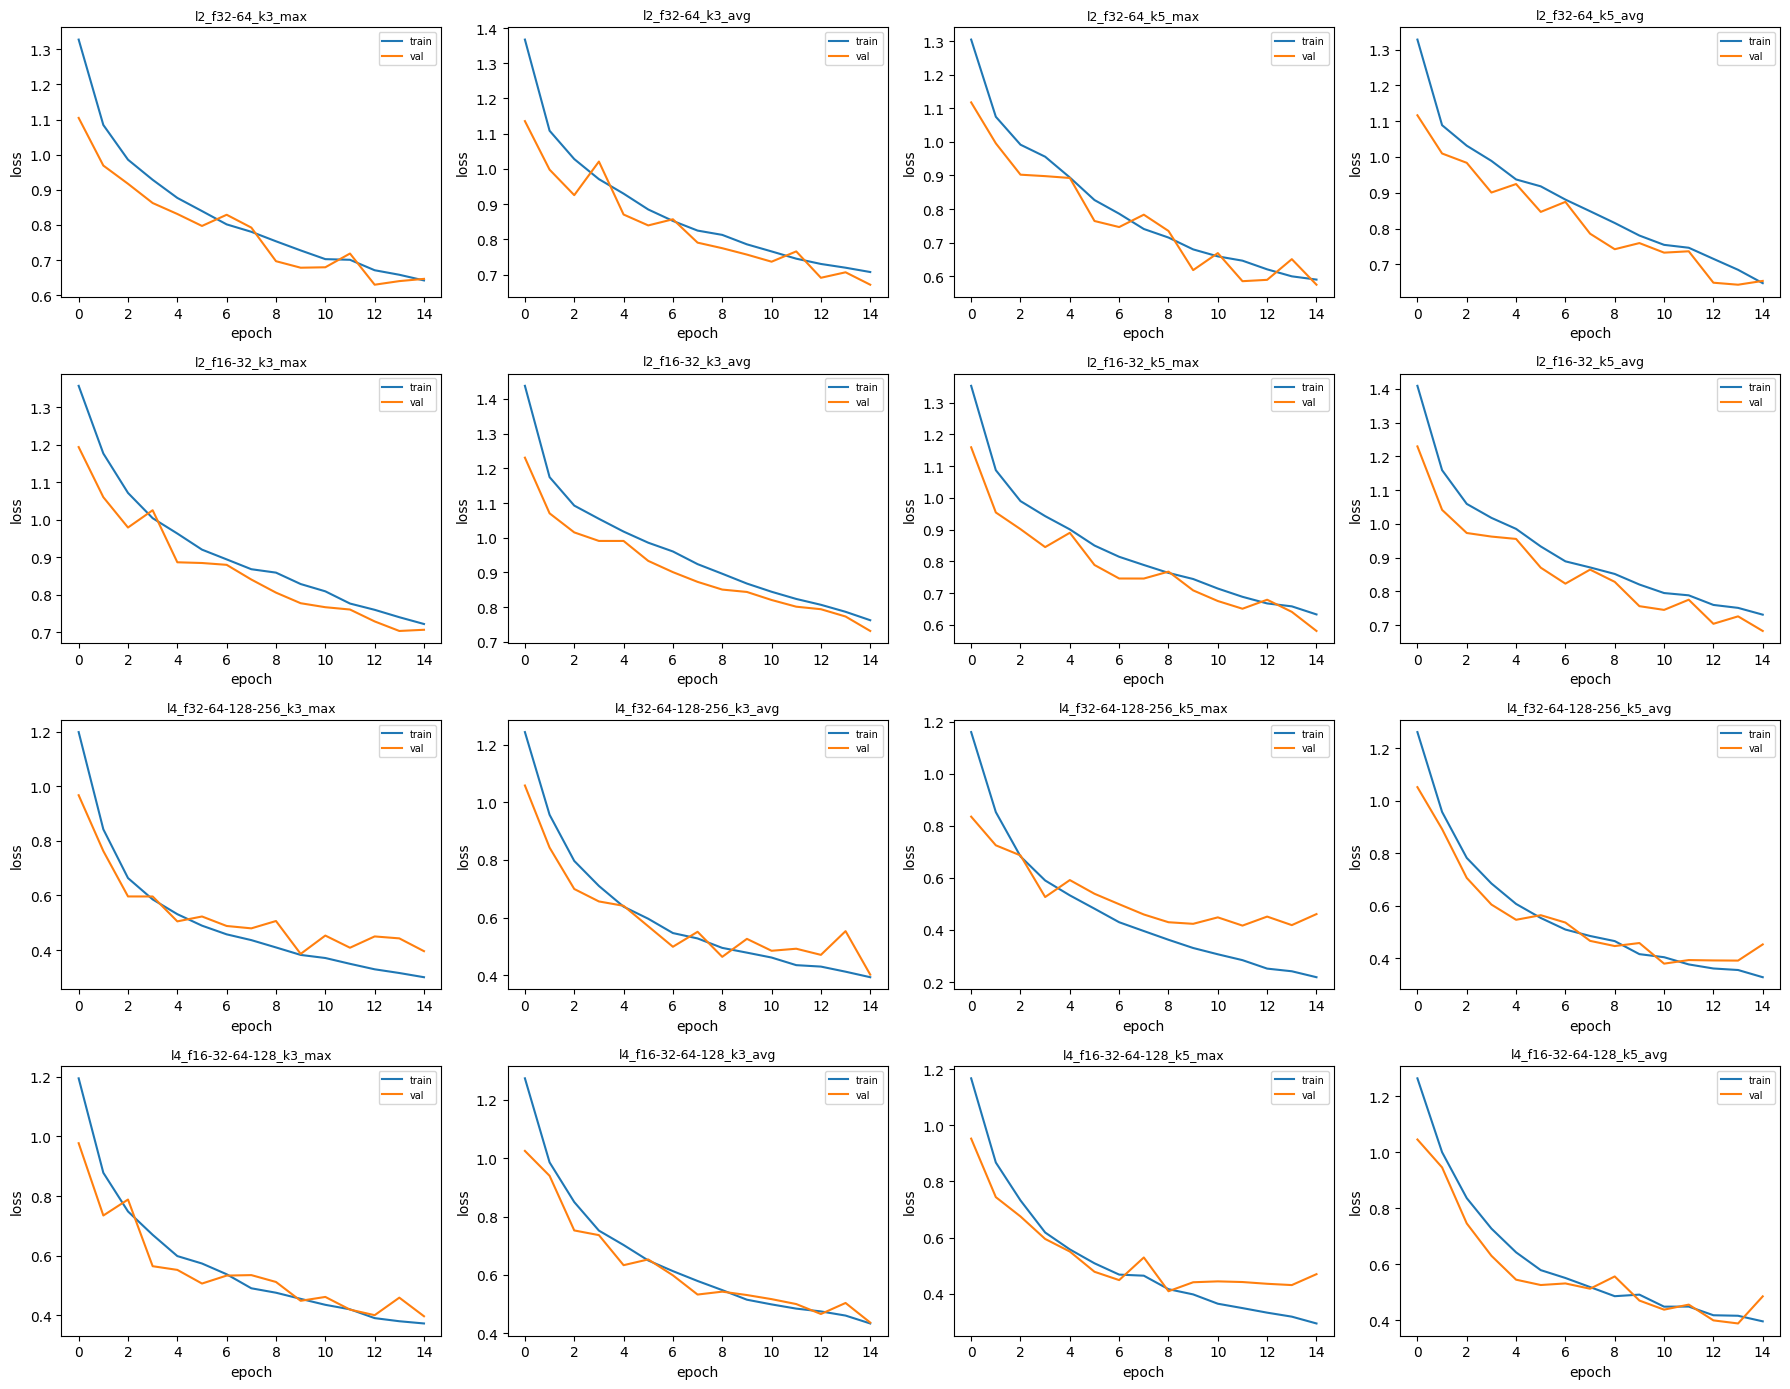

In [ ]:
# Plot training / validation loss curves for each variant.
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, (variant, art) in enumerate(cnn_results.items()):
    if i >= len(axes):
        break
    h = art['history']
    ax = axes[i]
    ax.plot(h.get('loss', []), label='train')
    ax.plot(h.get('val_loss', []), label='val')
    ax.set_title(variant, fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cnn_loss_curves.png', dpi=120)
plt.show()

## 3 CNN — From Scratch & Evaluation

Bandingkan macro F1 Keras vs from-scratch pada test set untuk arsitektur terbaik. Lalu
ulangi dengan Conv2D diganti LocallyConnected2D (shared vs non-shared).

In [8]:
from src.cnn.scratch_model import CNNScratchModel
from sklearn.metrics import f1_score

best_art = cnn_results[best_cnn_variant]
keras_best = best_art['model']
weights_file = MODELS_DIR / 'cnn' / (best_cnn_variant + '.weights.h5')
keras_best.load_weights(weights_file)

X_test, y_test = [], []
for xb, yb in test_ds:
    X_test.append(xb.numpy())
    y_test.append(yb.numpy())
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
print('test set shape:', X_test.shape, y_test.shape)

scratch_shared = CNNScratchModel.load_from_keras(keras_best)
scratch_preds = []
for i in range(X_test.shape[0]):
    logits = scratch_shared.forward(X_test[i])
    scratch_preds.append(int(np.argmax(logits)))
scratch_f1 = f1_score(y_test, scratch_preds, average='macro', zero_division=0)
print('Keras  macro F1:', best_art['test_macro_f1'])
print('Scratch macro F1:', scratch_f1)

test set shape: (3000, 150, 150, 3) (3000,)
Keras  macro F1: 0.8569575701404606
Scratch macro F1: 0.8569575701404606


In [9]:
from tensorflow.keras import layers as kl
from src.cnn.locally_connected_keras import LocallyConnected2D
import gc

tf.keras.backend.clear_session()
gc.collect()

cfg = dict(best_art['config'])

cfg['num_conv_layers'] = 3
cfg['filters_per_layer'] = [8, 16, 32]
cfg['kernel_size'] = 3
inputs = keras.Input(shape=tuple(cfg['input_shape']))
x = inputs
pool_cls = kl.MaxPooling2D if cfg['pooling_type'] == 'max' else kl.AveragePooling2D
for i in range(cfg['num_conv_layers']):
    x = LocallyConnected2D(
        filters=cfg['filters_per_layer'][i],
        kernel_size=cfg['kernel_size'],
        padding='valid',
        activation='relu',
    )(x)
    x = pool_cls(pool_size=(2, 2))(x)
    
x = kl.GlobalAveragePooling2D()(x)
x = kl.Dense(128, activation='relu')(x)
outputs = kl.Dense(len(class_names), activation='softmax')(x)
model_nonshared = keras.Model(inputs, outputs)
model_nonshared.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

SMALL_BATCH = 32 
small_train_ds = train_ds.unbatch().batch(SMALL_BATCH)
small_val_ds = val_ds.unbatch().batch(SMALL_BATCH)
small_test_ds = test_ds.unbatch().batch(SMALL_BATCH)
NONSHARED_EPOCHS = min(cfg['epochs'], 5)
history_nonshared = model_nonshared.fit(
    small_train_ds, 
    validation_data=small_val_ds, 
    epochs=NONSHARED_EPOCHS, 
    verbose=1
)
preds_ns = np.argmax(model_nonshared.predict(small_test_ds, verbose=0), axis=1)
f1_nonshared = f1_score(y_test, preds_ns, average='macro', zero_division=0)
n_shared = keras_best.count_params()
n_nonshared = model_nonshared.count_params()
print('shared params    :', n_shared)
print('non-shared params:', n_nonshared)
print('shared    F1 (Keras):', best_art['test_macro_f1'])
print('non-shared F1 (Keras):', f1_nonshared)
with open(OUT_DIR / 'cnn_shared_vs_nonshared.json', 'w', encoding='utf-8') as f:
    json.dump({
        'shared_f1': best_art['test_macro_f1'],
        'shared_scratch_f1': scratch_f1,
        'shared_params': int(n_shared),
        'nonshared_f1': float(f1_nonshared),
        'nonshared_params': int(n_nonshared),
    }, f, indent=2)

Epoch 1/5


I0000 00:00:1778945860.999218 1530082 cuda_dnn.cc:461] Loaded cuDNN version 90700
I0000 00:00:1778945888.412817 1530085 service.cc:153] XLA service 0x7fcc2d56e0d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778945888.412846 1530085 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.0)
I0000 00:00:1778945888.417104 1530085 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778945888.502567 1530085 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    373/Unknown - 57s 23ms/step - loss: 1.7470 - accuracy: 0.2078

I0000 00:00:1778945911.720709 1530212 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12837553203636639859
I0000 00:00:1778945911.720800 1530212 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8900942844167586829


373/373 [==============================] - 58s 26ms/step - loss: 1.7470 - accuracy: 0.2078 - val_loss: 1.4875 - val_accuracy: 0.3549
Epoch 2/5
  3/373 [..............................] - ETA: 11s - loss: 1.5147 - accuracy: 0.3021

I0000 00:00:1778945912.756201 1530398 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12837553203636639859
I0000 00:00:1778945912.756305 1530398 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8900942844167586829


373/373 [==============================] - 10s 26ms/step - loss: 1.3856 - accuracy: 0.4456 - val_loss: 1.2612 - val_accuracy: 0.4964
Epoch 3/5
373/373 [==============================] - 10s 26ms/step - loss: 1.2233 - accuracy: 0.5267 - val_loss: 1.1619 - val_accuracy: 0.5207
Epoch 4/5
373/373 [==============================] - 10s 26ms/step - loss: 1.0891 - accuracy: 0.5718 - val_loss: 1.0369 - val_accuracy: 0.5891
Epoch 5/5
373/373 [==============================] - 10s 26ms/step - loss: 1.0127 - accuracy: 0.6029 - val_loss: 1.0559 - val_accuracy: 0.5767


I0000 00:00:1778945953.010874 1530624 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8900942844167586829


shared params    : 1111750
non-shared params: 16330246
shared    F1 (Keras): 0.8569575701404606
non-shared F1 (Keras): 0.5890462763961076


In [ ]:
shared_history = best_art['history']

ns_loss     = history_nonshared.history['loss']
ns_val_loss = history_nonshared.history['val_loss']

shared_loss     = shared_history.get('loss', [])
shared_val_loss = shared_history.get('val_loss', [])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(1, len(shared_loss) + 1), shared_loss, label='train loss', marker='o')
ax.plot(range(1, len(shared_val_loss) + 1), shared_val_loss, label='val loss', marker='s')
ax.set_title(f'Shared (Conv2D)\n{best_cnn_variant}\nF1={best_art["test_macro_f1"]:.4f}, params={n_shared:,}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(ns_loss) + 1), ns_loss, label='train loss', marker='o', color='C2')
ax.plot(range(1, len(ns_val_loss) + 1), ns_val_loss, label='val loss', marker='s', color='C3')
ax.set_title(f'Non-Shared (LocallyConnected2D)\nl3_f8-16-32_k3_max\nF1={f1_nonshared:.4f}, params={n_nonshared:,}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Shared (Conv2D) vs Non-Shared (LocallyConnected2D) — Training & Validation Loss', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cnn_shared_vs_nonshared_loss.png', dpi=120)
plt.show()

print(f'Shared    — train epochs: {len(shared_loss)}, final val_loss: {shared_val_loss[-1]:.4f}')
print(f'Non-Shared — train epochs: {len(ns_loss)},  final val_loss: {ns_val_loss[-1]:.4f}')


## 4 CNN — Grad-CAM [Bonus]

Tampilkan intermediate feature maps + Grad-CAM heatmap untuk beberapa contoh per kelas.

last conv layer name: conv2d_27


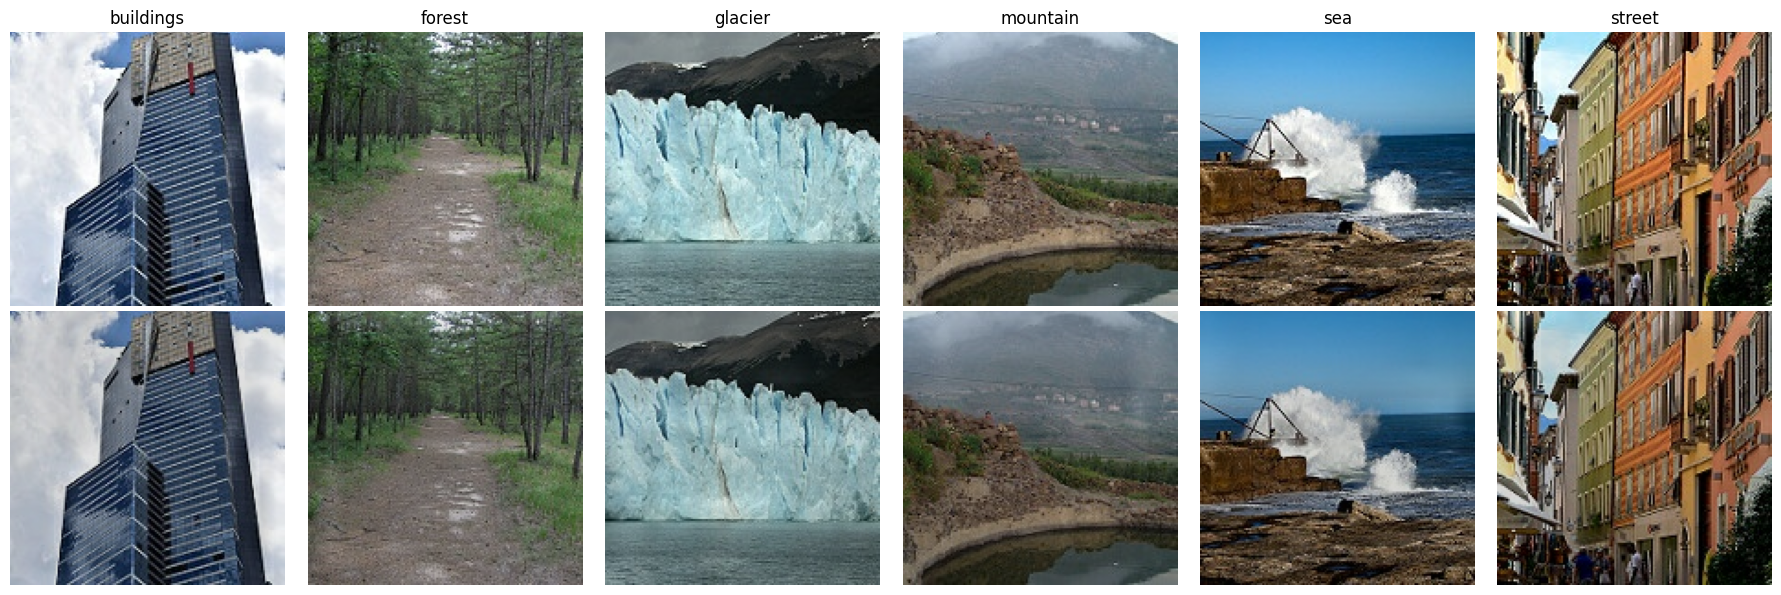

In [23]:
from src.cnn.gradcam import get_intermediate_feature_maps, grad_cam

last_conv = None
for layer in keras_best.layers:
    if 'conv' in layer.__class__.__name__.lower():
        last_conv = layer.name
print('last conv layer name:', last_conv)

examples = {}
for i in range(X_test.shape[0]):
    c = int(y_test[i])
    if c not in examples:
        examples[c] = i
    if len(examples) == len(class_names):
        break

fig, axes = plt.subplots(2, len(class_names), figsize=(3 * len(class_names), 6))
for col, (cls_idx, img_idx) in enumerate(sorted(examples.items())):
    img = X_test[img_idx]
    heatmap = grad_cam(keras_best, img, cls_idx, last_conv)
    axes[0, col].imshow(img)
    axes[0, col].set_title(class_names[cls_idx])
    axes[0, col].axis('off')
    axes[1, col].imshow(img)
    axes[1, col].imshow(heatmap, cmap='jet', alpha=0.4)
    axes[1, col].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'gradcam_examples.png', dpi=120)
plt.show()

## 5 RNN/LSTM — Feature Extraction + Caption Preprocessing

Ekstrak fitur CNN seluruh Flickr8k pakai InceptionV3 frozen (sekali saja). Lalu
preprocess captions: lowercase, strip punctuation, add <start>/<end>, build vocab.

In [8]:
from src.shared.image_utils import extract_and_save_features
from src.rnn_lstm.caption_preprocessing import (
    preprocess_captions, build_vocabulary, build_index_to_word, tokenize_and_pad,
    save_vocabulary, load_vocabulary, load_flickr8k_split, prepare_dataset,
)

IMG_DIR = FLICKR_DIR / 'images'
TOKEN_FILE = FLICKR_DIR / 'captions.txt'

image_files = sorted([p.name for p in IMG_DIR.glob('*.jpg')])
print('total Flickr8k images:', len(image_files))
image_paths = [str(IMG_DIR / name) for name in image_files]

encoder = keras.applications.InceptionV3(include_top=False, pooling='avg', weights='imagenet')
encoder.trainable = False

features = extract_and_save_features(
    image_paths,
    encoder,
    out_path=FEAT_DIR / 'features.npy',
    index_map_path=FEAT_DIR / 'index_map.json',
    skip_if_exists=True,
)
with open(FEAT_DIR / 'index_map.json') as f:
    index_map = json.load(f)
print('features shape:', features.shape)

total Flickr8k images: 0
features shape: (8091, 2048)


In [9]:
from src.rnn_lstm.caption_preprocessing import generate_splits, preprocess_captions

captions_by_image = preprocess_captions(TOKEN_FILE)
train_ids, val_ids, test_ids = generate_splits(captions_by_image.keys())
print('train/val/test image counts:', len(train_ids), len(val_ids), len(test_ids))

train_captions_flat = []
for img in train_ids:
    if img in captions_by_image:
        train_captions_flat.extend(captions_by_image[img])
word2idx = build_vocabulary(train_captions_flat, min_freq=2)
idx2word = build_index_to_word(word2idx)
print('vocab size:', len(word2idx))

save_vocabulary(word2idx, CAP_DIR / 'vocab.json')

MAX_LEN = 35
train_feats, train_in, train_tgt = prepare_dataset(
    captions_by_image, train_ids, features, index_map, word2idx, MAX_LEN
)
val_feats, val_in, val_tgt = prepare_dataset(
    captions_by_image, val_ids, features, index_map, word2idx, MAX_LEN
)
print('train:', train_feats.shape, train_in.shape, train_tgt.shape)
print('val  :', val_feats.shape, val_in.shape, val_tgt.shape)

np.save(CAP_DIR / 'sequences_train.npy', train_in)
np.save(CAP_DIR / 'sequences_val.npy', val_in)

train/val/test image counts: 6472 809 810
vocab size: 4701
train: (32360, 2048) (32360, 34) (32360, 34)
val  : (4045, 2048) (4045, 34) (4045, 34)


## 6 RNN/LSTM — Training (RNN & LSTM variants)

Spec Bagian 3: 12 variants = 2 decoders (SimpleRNN, LSTM) x 3 layer counts x 2 hidden sizes.

In [10]:
from src.rnn_lstm.train import hyperparameter_grid as rnn_grid, train_grid as rnn_train_grid

EPOCHS_DEC = 20
BATCH_DEC = 64

decoder_configs = rnn_grid(epochs=EPOCHS_DEC, batch_size=BATCH_DEC)
print('total decoder variants:', len(decoder_configs))
for c in decoder_configs:
    print(' -', c.variant_name())

decoder_results = rnn_train_grid(
    decoder_configs,
    train_features=train_feats,
    train_decoder_input=train_in,
    train_decoder_target=train_tgt,
    val_features=val_feats,
    val_decoder_input=val_in,
    val_decoder_target=val_tgt,
    vocab_size=len(word2idx),
    output_root=MODELS_DIR,
    verbose=1,
)

total decoder variants: 12
 - pre_inject_lstm_l1_h128_e256
 - pre_inject_lstm_l1_h512_e256
 - pre_inject_lstm_l2_h128_e256
 - pre_inject_lstm_l2_h512_e256
 - pre_inject_lstm_l3_h128_e256
 - pre_inject_lstm_l3_h512_e256
 - pre_inject_rnn_l1_h128_e256
 - pre_inject_rnn_l1_h512_e256
 - pre_inject_rnn_l2_h128_e256
 - pre_inject_rnn_l2_h512_e256
 - pre_inject_rnn_l3_h128_e256
 - pre_inject_rnn_l3_h512_e256
Resuming pre_inject_lstm_l1_h128_e256 - already trained.
Resuming pre_inject_lstm_l1_h512_e256 - already trained.
Resuming pre_inject_lstm_l2_h128_e256 - already trained.
Resuming pre_inject_lstm_l2_h512_e256 - already trained.
Resuming pre_inject_lstm_l3_h128_e256 - already trained.
Resuming pre_inject_lstm_l3_h512_e256 - already trained.
Resuming pre_inject_rnn_l1_h128_e256 - already trained.
Resuming pre_inject_rnn_l1_h512_e256 - already trained.
Resuming pre_inject_rnn_l2_h128_e256 - already trained.
Resuming pre_inject_rnn_l2_h512_e256 - already trained.
Resuming pre_inject_rnn_l3_h1

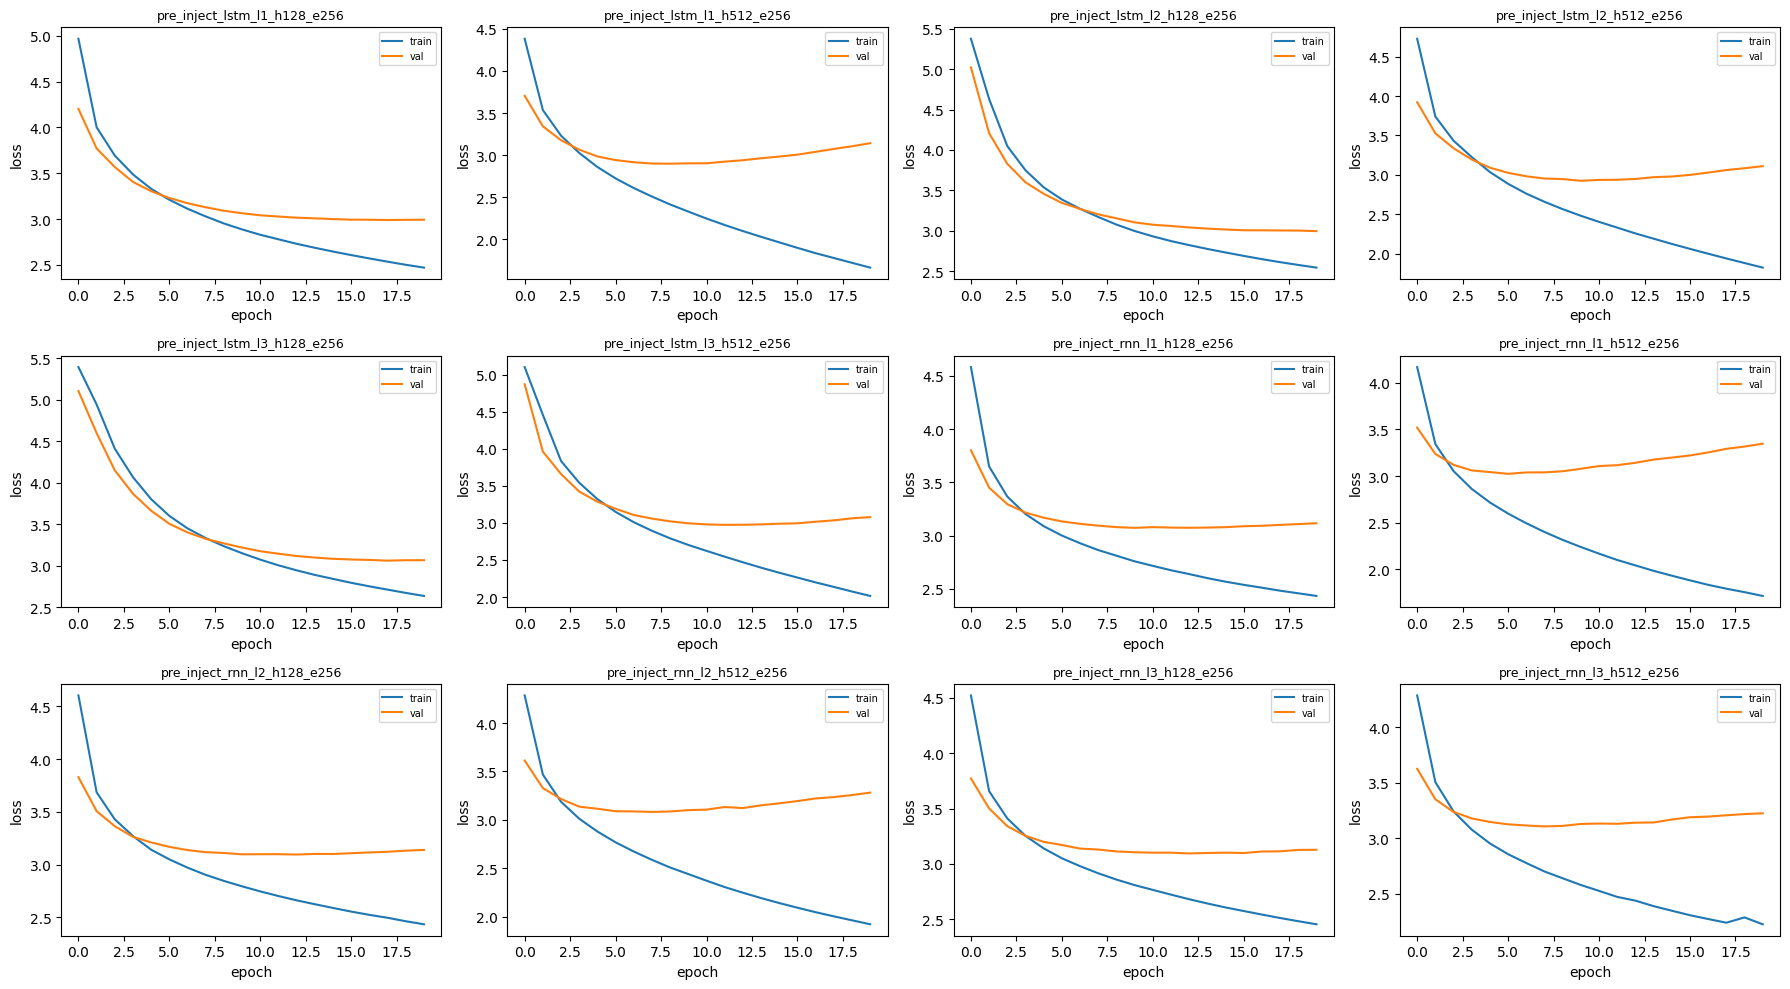

In [11]:
# Plot training / validation loss for each decoder variant.
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, (variant, art) in enumerate(decoder_results.items()):
    h = art['history']
    ax = axes[i]
    ax.plot(h.get('loss', []), label='train')
    ax.plot(h.get('val_loss', []), label='val')
    ax.set_title(variant, fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / 'rnn_lstm_loss_curves.png', dpi=120)
plt.show()

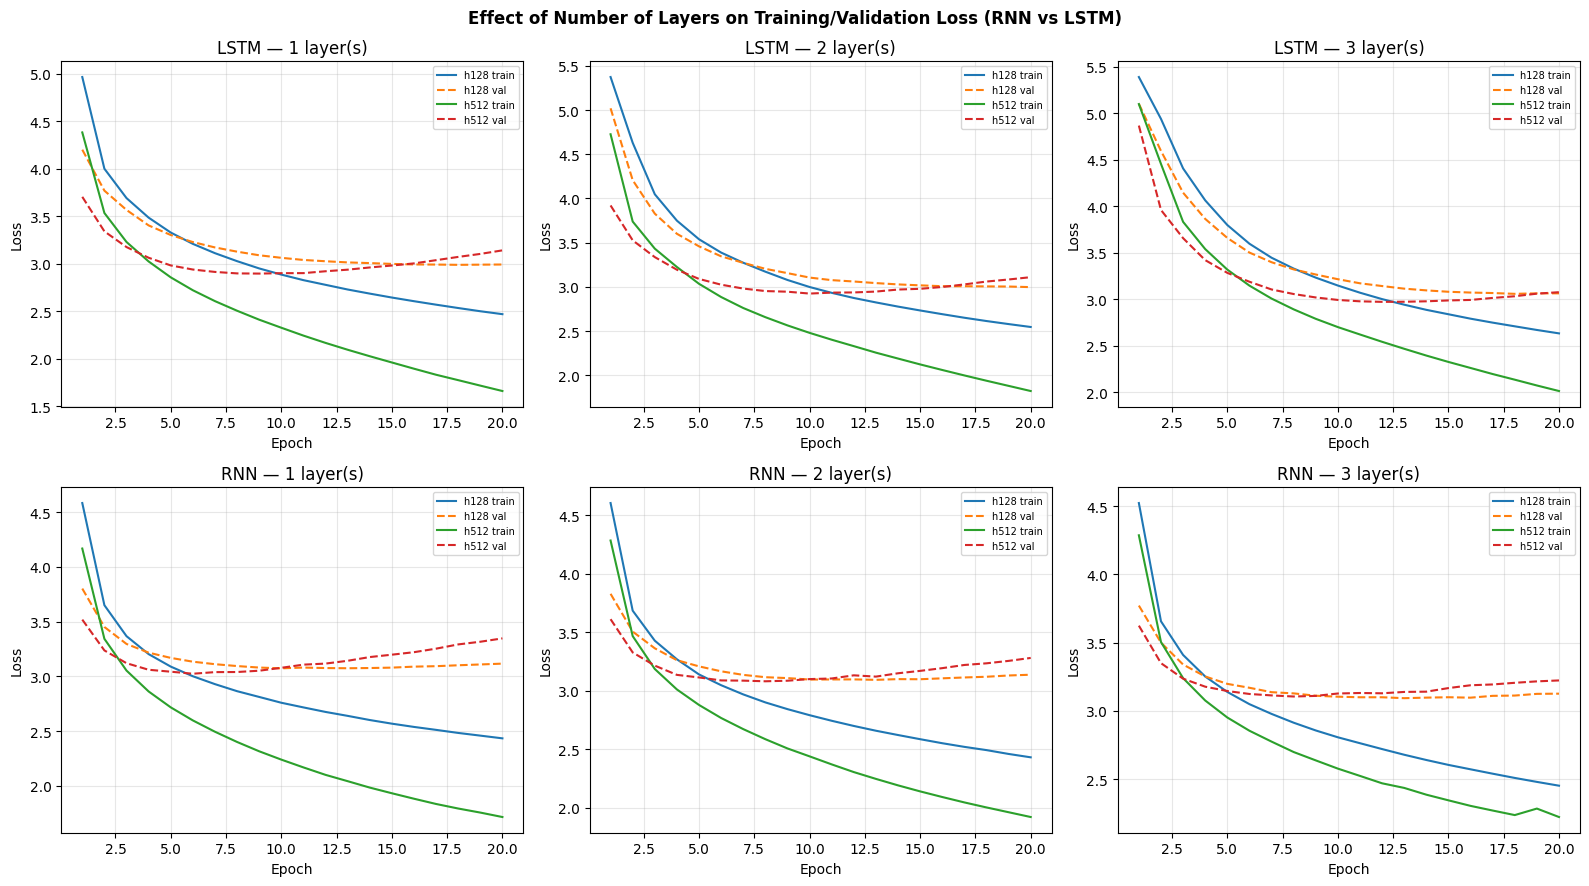

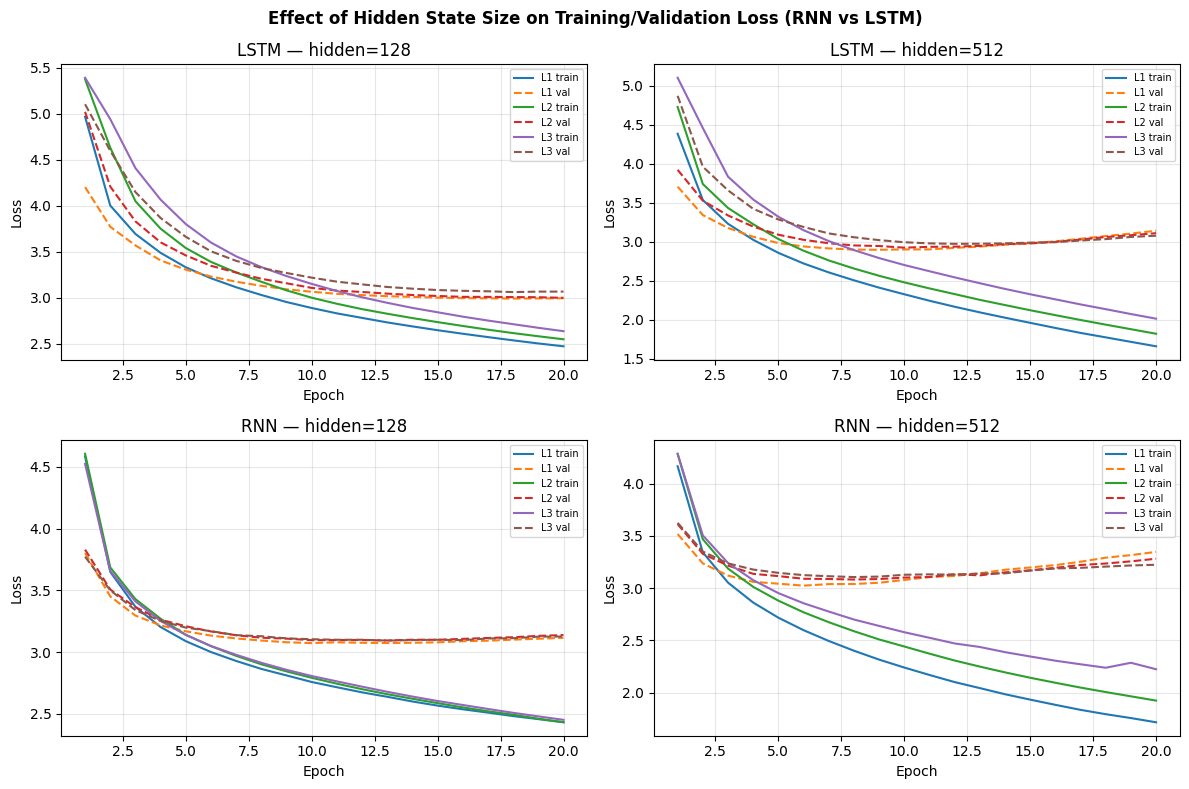

In [25]:
import re

fig_layers, axes_layers = plt.subplots(2, 3, figsize=(16, 9))
fig_hidden, axes_hidden = plt.subplots(2, 2, figsize=(12, 8))

def parse_variant(v):
    m = re.search(r'(lstm|rnn)_l(\d+)_h(\d+)', v)
    if m:
        return m.group(1), int(m.group(2)), int(m.group(3))
    return None, None, None

layer_counts = [1, 2, 3]
for col, nl in enumerate(layer_counts):
    for row, rnn_type in enumerate(['lstm', 'rnn']):
        ax = axes_layers[row, col]
        matched = [(v, art) for v, art in decoder_results.items()
                   if parse_variant(v)[0] == rnn_type and parse_variant(v)[1] == nl]
        for v, art in matched:
            _, _, hd = parse_variant(v)
            h = art['history']
            epochs = range(1, len(h.get('loss', [])) + 1)
            ax.plot(epochs, h.get('loss', []), label=f'h{hd} train', linestyle='-')
            ax.plot(epochs, h.get('val_loss', []), label=f'h{hd} val', linestyle='--')
        ax.set_title(f'{rnn_type.upper()} — {nl} layer(s)')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

fig_layers.suptitle('Effect of Number of Layers on Training/Validation Loss (RNN vs LSTM)', fontsize=12, fontweight='bold')
fig_layers.tight_layout()
fig_layers.savefig(OUT_DIR / 'rnn_lstm_layers_comparison.png', dpi=120)

hidden_dims = [128, 512]
for row, rnn_type in enumerate(['lstm', 'rnn']):
    for col, hd in enumerate(hidden_dims):
        ax = axes_hidden[row, col]
        matched = [(v, art) for v, art in decoder_results.items()
                   if parse_variant(v)[0] == rnn_type and parse_variant(v)[2] == hd]
        for v, art in sorted(matched, key=lambda x: parse_variant(x[0])[1]):
            _, nl, _ = parse_variant(v)
            h = art['history']
            epochs = range(1, len(h.get('loss', [])) + 1)
            ax.plot(epochs, h.get('loss', []), label=f'L{nl} train', linestyle='-')
            ax.plot(epochs, h.get('val_loss', []), label=f'L{nl} val', linestyle='--')
        ax.set_title(f'{rnn_type.upper()} — hidden={hd}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

fig_hidden.suptitle('Effect of Hidden State Size on Training/Validation Loss (RNN vs LSTM)', fontsize=12, fontweight='bold')
fig_hidden.tight_layout()
fig_hidden.savefig(OUT_DIR / 'rnn_lstm_hidden_comparison.png', dpi=120)


## 7 RNN/LSTM — From Scratch & Evaluation

Evaluasi semua 12 varian Keras pada test set (BLEU-4 + METEOR). Pilih best RNN dan best LSTM,
lalu bandingkan dengan implementasi from-scratch.

In [15]:
from src.rnn_lstm.evaluate import (
    evaluate_keras_decoder, evaluate_scratch_decoder, evaluate_beam_decoder,
    select_qualitative_examples, sweep_max_caption_length, compare_results,
)
from src.rnn_lstm.decoder import ImageCaptionerScratch

from src.rnn_lstm.train import load_model_from_artefact

def features_for(image_ids):
    rows = [features[index_map[i]] for i in image_ids if i in index_map]
    return np.stack(rows, axis=0)
test_image_ids = [i for i in test_ids if i in index_map and i in captions_by_image]
test_feats_ev = features_for(test_image_ids)

def strip_wrap(c):
    return c.replace('<start> ', '').replace(' <end>', '').strip()
refs_by_image = {img: [strip_wrap(c) for c in captions_by_image[img]] for img in test_image_ids}
SEQ_LEN = MAX_LEN - 1  

eval_file = OUT_DIR / 'rnn_lstm_keras_eval.json'
if eval_file.exists():
    with open(eval_file, 'r', encoding='utf-8') as f:
        all_eval_rows = json.load(f)
    evaluated_variants = {row['variant'] for row in all_eval_rows}
    print(f"Loaded {len(all_eval_rows)} existing evaluations from disk.")
else:
    all_eval_rows = []
    evaluated_variants = set()
feat_dim = train_feats.shape[1]
seq_length = train_in.shape[1]
vocab_size = len(word2idx)
for variant, art in decoder_results.items():
    if variant in evaluated_variants:
        print(f"Skipping {variant}, already evaluated.")
        continue
        
    print(f"Evaluating {variant}...")
    
    model = load_model_from_artefact(
        art,
        output_root=MODELS_DIR,
        vocab_size=vocab_size,
        feat_dim=feat_dim,
        seq_len=seq_length
    )
    
    res = evaluate_keras_decoder(
        model,
        features=test_feats_ev,
        image_ids=test_image_ids,
        references_by_image=refs_by_image,
        idx2word=idx2word,
        seq_len=SEQ_LEN,
        max_len=20,
        variant=variant,
    )
    
    print(variant, 'BLEU-4:', round(res.bleu4, 4), 'METEOR:', round(res.meteor, 4))
    all_eval_rows.append(res.to_dict() | {'variant': variant})
    
    with open(eval_file, 'w', encoding='utf-8') as f:
        json.dump(all_eval_rows, f, indent=2)

    del model
    tf.keras.backend.clear_session()
    gc.collect()
print("Evaluation complete!")

Loaded 1 existing evaluations from disk.
Skipping pre_inject_lstm_l1_h128_e256, already evaluated.
Evaluating pre_inject_lstm_l1_h512_e256...


pre_inject_lstm_l1_h512_e256 BLEU-4: 0.131 METEOR: 0.3453
Evaluating pre_inject_lstm_l2_h128_e256...


pre_inject_lstm_l2_h128_e256 BLEU-4: 0.1234 METEOR: 0.3274
Evaluating pre_inject_lstm_l2_h512_e256...


pre_inject_lstm_l2_h512_e256 BLEU-4: 0.1522 METEOR: 0.3534
Evaluating pre_inject_lstm_l3_h128_e256...


pre_inject_lstm_l3_h128_e256 BLEU-4: 0.1098 METEOR: 0.3196
Evaluating pre_inject_lstm_l3_h512_e256...


...

Evaluating pre_inject_rnn_l1_h512_e256...
pre_inject_rnn_l1_h512_e256 BLEU-4: 0.1223 METEOR: 0.3266
Evaluating pre_inject_rnn_l2_h128_e256...


pre_inject_rnn_l2_h128_e256 BLEU-4: 0.0938 METEOR: 0.2961
Evaluating pre_inject_rnn_l2_h512_e256...


pre_inject_rnn_l2_h512_e256 BLEU-4: 0.135 METEOR: 0.3309
Evaluating pre_inject_rnn_l3_h128_e256...


pre_inject_rnn_l3_h128_e256 BLEU-4: 0.1036 METEOR: 0.3103
Evaluating pre_inject_rnn_l3_h512_e256...


pre_inject_rnn_l3_h512_e256 BLEU-4: 0.139 METEOR: 0.334
Evaluation complete!


In [16]:
# Pick the best LSTM and best RNN (highest BLEU-4) for Keras vs scratch comparison.
def best_of(rows, kind):
    candidates = [r for r in rows if kind in r['variant']]
    return sorted(candidates, key=lambda r: r['bleu4'], reverse=True)[0]

best_lstm = best_of(all_eval_rows, 'lstm')
best_rnn  = best_of(all_eval_rows, 'rnn')
print('best LSTM:', best_lstm['variant'], 'BLEU-4:', best_lstm['bleu4'])
print('best RNN :', best_rnn['variant'],  'BLEU-4:', best_rnn['bleu4'])

best LSTM: pre_inject_lstm_l2_h512_e256 BLEU-4: 0.15217236299799197
best RNN : pre_inject_rnn_l3_h512_e256 BLEU-4: 0.13896498835799684


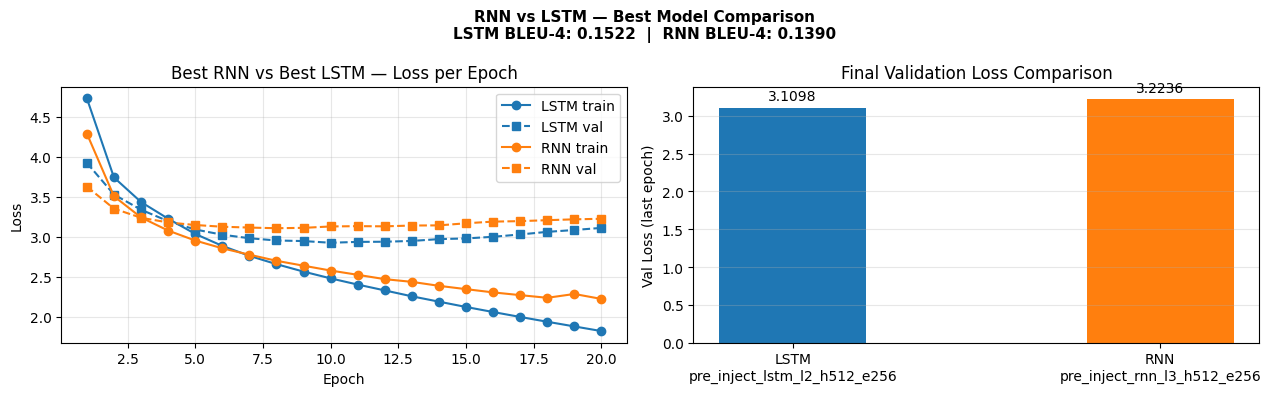

In [26]:
best_lstm_art = decoder_results[best_lstm['variant']]
best_rnn_art  = decoder_results[best_rnn['variant']]

lstm_loss     = best_lstm_art['history'].get('loss', [])
lstm_val_loss = best_lstm_art['history'].get('val_loss', [])
rnn_loss      = best_rnn_art['history'].get('loss', [])
rnn_val_loss  = best_rnn_art['history'].get('val_loss', [])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(1, len(lstm_loss)+1), lstm_loss, label='LSTM train', color='C0', marker='o')
ax.plot(range(1, len(lstm_val_loss)+1), lstm_val_loss, label='LSTM val', color='C0', linestyle='--', marker='s')
ax.plot(range(1, len(rnn_loss)+1), rnn_loss, label='RNN train', color='C1', marker='o')
ax.plot(range(1, len(rnn_val_loss)+1), rnn_val_loss, label='RNN val', color='C1', linestyle='--', marker='s')
ax.set_title('Best RNN vs Best LSTM — Loss per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
labels = [f'LSTM\n{best_lstm["variant"]}', f'RNN\n{best_rnn["variant"]}']
final_vals = [lstm_val_loss[-1] if lstm_val_loss else 0,
              rnn_val_loss[-1] if rnn_val_loss else 0]
bars = ax.bar(labels, final_vals, color=['C0', 'C1'], width=0.4)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_title('Final Validation Loss Comparison')
ax.set_ylabel('Val Loss (last epoch)')
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'RNN vs LSTM — Best Model Comparison\n'
             f'LSTM BLEU-4: {best_lstm["bleu4"]:.4f}  |  RNN BLEU-4: {best_rnn["bleu4"]:.4f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'rnn_vs_lstm_best_loss.png', dpi=120)
plt.show()


In [18]:
from src.rnn_lstm.train import load_model_from_artefact

lstm_model = load_model_from_artefact(
    decoder_results[best_lstm['variant']],
    output_root=MODELS_DIR,
    vocab_size=len(word2idx),
    feat_dim=train_feats.shape[1],
    seq_len=train_in.shape[1]
)
rnn_model = load_model_from_artefact(
    decoder_results[best_rnn['variant']],
    output_root=MODELS_DIR,
    vocab_size=len(word2idx),
    feat_dim=train_feats.shape[1],
    seq_len=train_in.shape[1]
)

scratch_lstm = ImageCaptionerScratch.load_from_keras(lstm_model, cnn_encoder=None, word2idx=word2idx, idx2word=idx2word)
scratch_rnn  = ImageCaptionerScratch.load_from_keras(rnn_model,  cnn_encoder=None, word2idx=word2idx, idx2word=idx2word)

scratch_lstm_res = evaluate_scratch_decoder(
    scratch_lstm, test_feats_ev, test_image_ids, refs_by_image,
    max_len=20, variant=best_lstm['variant'] + '_scratch',
)
scratch_rnn_res = evaluate_scratch_decoder(
    scratch_rnn, test_feats_ev, test_image_ids, refs_by_image,
    max_len=20, variant=best_rnn['variant'] + '_scratch',
)

comparison = {
    'lstm_keras':   best_lstm,
    'lstm_scratch': scratch_lstm_res.to_dict(),
    'rnn_keras':    best_rnn,
    'rnn_scratch':  scratch_rnn_res.to_dict(),
}
with open(OUT_DIR / 'rnn_lstm_keras_vs_scratch.json', 'w', encoding='utf-8') as f:
    json.dump(comparison, f, indent=2)
print(json.dumps(comparison, indent=2))

/workspace/src/shared/activations.py:28: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x_clipped))


{
  "lstm_keras": {
    "variant": "pre_inject_lstm_l2_h512_e256",
    "decoder_kind": "keras",
    "bleu4": 0.15217236299799197,
    "meteor": 0.3534038363789836,
    "elapsed_seconds": 476.0595874786377,
    "num_samples": 810
  },
  "lstm_scratch": {
    "variant": "pre_inject_lstm_l2_h512_e256_scratch",
    "decoder_kind": "scratch",
    "bleu4": 0.15217236299799197,
    "meteor": 0.3534038363789836,
    "elapsed_seconds": 24.24315118789673,
    "num_samples": 810
  },
  "rnn_keras": {
    "variant": "pre_inject_rnn_l3_h512_e256",
    "decoder_kind": "keras",
    "bleu4": 0.13896498835799684,
    "meteor": 0.33404904302713795,
    "elapsed_seconds": 533.8717949390411,
    "num_samples": 810
  },
  "rnn_scratch": {
    "variant": "pre_inject_rnn_l3_h512_e256_scratch",
    "decoder_kind": "scratch",
    "bleu4": 0.1390014527352426,
    "meteor": 0.334058665461854,
    "elapsed_seconds": 11.880263090133667,
    "num_samples": 810
  }
}


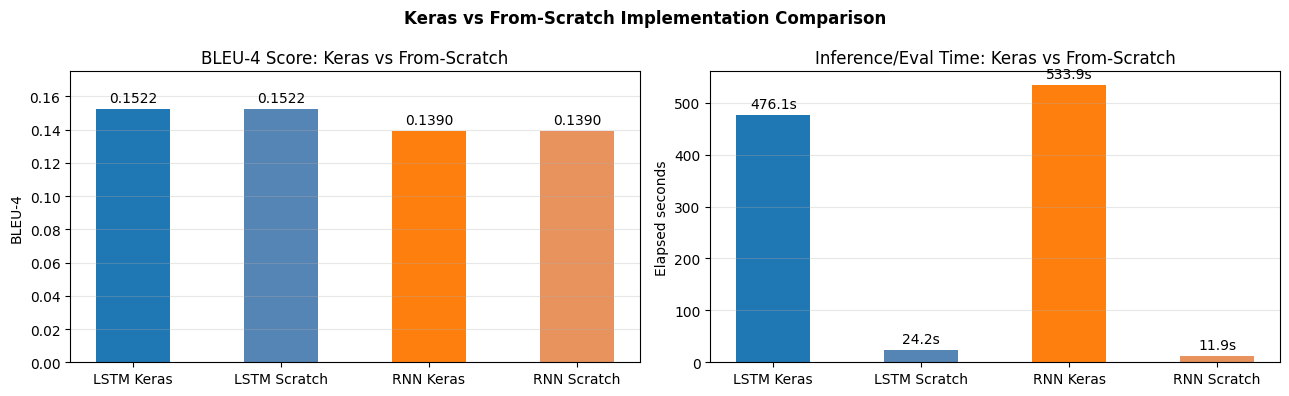


Note: Training/validation loss curves are the same for Keras and Scratch,
because Scratch loads weights directly from the trained Keras model (no retraining).


In [27]:
labels  = ['LSTM Keras', 'LSTM Scratch', 'RNN Keras', 'RNN Scratch']
bleu4s  = [
    best_lstm['bleu4'],
    scratch_lstm_res.bleu4,
    best_rnn['bleu4'],
    scratch_rnn_res.bleu4,
]
times   = [
    best_lstm.get('elapsed_seconds', 0),
    scratch_lstm_res.elapsed_seconds,
    best_rnn.get('elapsed_seconds', 0),
    scratch_rnn_res.elapsed_seconds,
]

colors = ['C0', '#5585b5', 'C1', '#e8925e']
x = range(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.bar(labels, bleu4s, color=colors, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_title('BLEU-4 Score: Keras vs From-Scratch')
ax.set_ylabel('BLEU-4')
ax.set_ylim(0, max(bleu4s) * 1.15)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
bars2 = ax.bar(labels, times, color=colors, width=0.5)
ax.bar_label(bars2, fmt='%.1fs', padding=3)
ax.set_title('Inference/Eval Time: Keras vs From-Scratch')
ax.set_ylabel('Elapsed seconds')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Keras vs From-Scratch Implementation Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'keras_vs_scratch_comparison.png', dpi=120)
plt.show()

print("\nNote: Training/validation loss curves are the same for Keras and Scratch,")
print("because Scratch loads weights directly from the trained Keras model (no retraining).")

In [19]:
# Qualitative analysis
qual_lstm = select_qualitative_examples(scratch_lstm_res, n_high=4, n_mid=3, n_low=3)
qual_rnn  = select_qualitative_examples(scratch_rnn_res,  n_high=4, n_mid=3, n_low=3)
print('LSTM qualitative count:', len(qual_lstm))
print('RNN  qualitative count:', len(qual_rnn))

for ex in qual_lstm[:5]:
    print('---')
    print(' image:', ex['image_id'], '  BLEU-4:', round(ex['score'], 4))
    print(' pred :', ex['prediction'])
    print(' refs :', ex['references'][0])

with open(OUT_DIR / 'qualitative_examples.json', 'w', encoding='utf-8') as f:
    json.dump({'lstm': qual_lstm, 'rnn': qual_rnn}, f, indent=2)

LSTM qualitative count: 10
RNN  qualitative count: 10
---
 image: 3455920874_6fbec43194.jpg   BLEU-4: 0.9036
 pred : a black and white dog jumps over a hurdle
 refs : a black and white dog in midair over a hurdle
---
 image: 3701249979_8bc757e171.jpg   BLEU-4: 0.0153
 pred : a young girl wearing a pink shirt and a girl in a red dress runs through a field
 refs : two children carry flowers as they walk along a grassy track
---
 image: 3279025792_23bfd21bcc.jpg   BLEU-4: 1.0
 pred : a black dog is running through the snow
 refs : a black dog is running through the snow
---
 image: 1525153022_06c48dbe52.jpg   BLEU-4: 1.0
 pred : a black dog is running through the water
 refs : a black dog is running through the shallow edge of a large body of water
---
 image: 1473618073_7db56a5237.jpg   BLEU-4: 0.0773
 pred : two children swing on a tire swing
 refs : a boy on a green plastic swing


In [20]:
candidates = [
    ('lstm_keras', best_lstm['bleu4'], best_lstm['elapsed_seconds']),
    ('lstm_scratch', scratch_lstm_res.bleu4, scratch_lstm_res.elapsed_seconds),
    ('rnn_keras', best_rnn['bleu4'], best_rnn['elapsed_seconds']),
    ('rnn_scratch', scratch_rnn_res.bleu4, scratch_rnn_res.elapsed_seconds),
]
candidates.sort(key=lambda c: c[1] - 1e-6 * c[2], reverse=True)
winner = candidates[0][0]
print('overall winner:', winner)

if winner.startswith('lstm'):
    cap = scratch_lstm
    variant_tag = best_lstm['variant']
else:
    cap = scratch_rnn
    variant_tag = best_rnn['variant']

sweep_results = sweep_max_caption_length(
    eval_fn=evaluate_scratch_decoder,
    max_lens=[10, 20, 35],
    captioner=cap,
    features=test_feats_ev,
    image_ids=test_image_ids,
    references_by_image=refs_by_image,
    variant=variant_tag,
)
for r in sweep_results:
    print(r.variant, 'BLEU-4:', round(r.bleu4, 4), 'METEOR:', round(r.meteor, 4))
with open(OUT_DIR / 'max_len_sweep.json', 'w', encoding='utf-8') as f:
    json.dump([r.to_dict() for r in sweep_results], f, indent=2)

overall winner: lstm_scratch
pre_inject_lstm_l2_h512_e256_L10 BLEU-4: 0.1657 METEOR: 0.3431
pre_inject_lstm_l2_h512_e256_L20 BLEU-4: 0.1522 METEOR: 0.3534
pre_inject_lstm_l2_h512_e256_L35 BLEU-4: 0.152 METEOR: 0.3536


## 8 RNN/LSTM — Beam Search / Init-Inject [Bonus]

In [21]:
# Beam search vs greedy, k = 3 and k = 5.
for k in [3, 5]:
    res = evaluate_beam_decoder(
        scratch_lstm,
        features=test_feats_ev,
        image_ids=test_image_ids,
        references_by_image=refs_by_image,
        max_len=20,
        beam_width=k,
        variant=best_lstm['variant'] + f'_beam{k}',
    )
    print('beam k=', k, ' BLEU-4:', round(res.bleu4, 4), ' METEOR:', round(res.meteor, 4))

beam k= 3  BLEU-4: 0.1615  METEOR: 0.3468
beam k= 5  BLEU-4: 0.1521  METEOR: 0.3335


In [ ]:
from src.rnn_lstm.train import DecoderConfig, train_decoder_config, load_model_from_artefact

init_configs = [
    DecoderConfig(rnn_type='lstm', num_layers=1, hidden_dim=256, architecture='init_inject', epochs=EPOCHS_DEC),
    DecoderConfig(rnn_type='rnn',  num_layers=1, hidden_dim=256, architecture='init_inject', epochs=EPOCHS_DEC),
]

init_results = {}
for cfg in init_configs:
    art = train_decoder_config(
        cfg,
        train_features=train_feats,
        train_decoder_input=train_in,
        train_decoder_target=train_tgt,
        val_features=val_feats,
        val_decoder_input=val_in,
        val_decoder_target=val_tgt,
        vocab_size=len(word2idx),
        output_dir=MODELS_DIR / cfg.rnn_type,
        verbose=1,
    )
    
    model = load_model_from_artefact(
        art,
        output_root=MODELS_DIR,
        vocab_size=len(word2idx),
        feat_dim=train_feats.shape[1],
        seq_len=train_in.shape[1]
    )
    
    res = evaluate_keras_decoder(
        model, 
        test_feats_ev, 
        test_image_ids, 
        refs_by_image,
        idx2word=idx2word, 
        seq_len=SEQ_LEN, 
        max_len=20,
        variant=cfg.variant_name(),
    )
    
    init_results[cfg.variant_name()] = {
        'bleu4': res.bleu4,
        'meteor': res.meteor,
        'elapsed': art['elapsed_seconds']
    }
    
    del model
    tf.keras.backend.clear_session()
    gc.collect()

with open(OUT_DIR / 'init_inject_results.json', 'w', encoding='utf-8') as f:
    json.dump(init_results, f, indent=2)

Epoch 1/20
506/506 [==============================] - 22s 35ms/step - loss: 4.4482 - masked_accuracy: 0.2556 - val_loss: 3.7504 - val_masked_accuracy: 0.3094
Epoch 2/20
506/506 [==============================] - 12s 24ms/step - loss: 3.6080 - masked_accuracy: 0.3298 - val_loss: 3.4231 - val_masked_accuracy: 0.3418
Epoch 3/20
506/506 [==============================] - 13s 26ms/step - loss: 3.3280 - masked_accuracy: 0.3527 - val_loss: 3.2564 - val_masked_accuracy: 0.3568
Epoch 4/20
506/506 [==============================] - 12s 24ms/step - loss: 3.1479 - masked_accuracy: 0.3686 - val_loss: 3.1504 - val_masked_accuracy: 0.3670
Epoch 5/20
506/506 [==============================] - 12s 24ms/step - loss: 3.0049 - masked_accuracy: 0.3818 - val_loss: 3.0749 - val_masked_accuracy: 0.3747
Epoch 6/20
506/506 [==============================] - 12s 24ms/step - loss: 2.8843 - masked_accuracy: 0.3940 - val_loss: 3.0172 - val_masked_accuracy: 0.3837
Epoch 7/20
506/506 [==============================] 